# MBQS Example: Analog QPU (Neutral atoms, Pulser emulation)

This notebooks exemplifies the use of the `mbqs` package to compute the $\mathrm{MBQS}_\downarrow$ score of a noisy emulator of a neutral atom QPU using Pulser.

## Setup

In [1]:
import logging

In [2]:
from mbqs import MBQS, MBQSProtocol, RydbergMapping
from mbqs.simulations.lattice import ring_coordinates

In [3]:
import pulser
from emu_mps import (
    BitStrings,
    MPSBackend,
    MPSConfig,
)
from pulser.devices import AnalogDevice

## MBQS Protocol with Pulser

In [4]:
noise_params = {
    "relaxation_rate": 1 / 100.0,
    "dephasing_rate": 1 / 4.5,
    # "p_false_neg": 0.1,
    # "p_false_pos": 0.02,
    # "state_prep_error": 0.01,
}

In [5]:
class Protocol:
    def __init__(self, *, L, a=7.5):
        self.L = L

        self.rydberg_map = RydbergMapping(L=L, a=a)
        self.protocol = MBQSProtocol(L=L, J=self.rydberg_map.J, state="down")

        self.device = AnalogDevice
        self.register = ring_register(self.device, L=L, a=a)

        self.sequence = mbqs_sequence(
            self.register,
            self.device,
            self.rydberg_map.delta,
            self.rydberg_map.Omega,
            self.protocol.surge_time,
        )

    def run(self, shots=1000, dt=0.01, noisy=True):

        return mbqs_emulation(self.sequence, shots=shots, dt=dt, noisy=noisy)

In [6]:
def ring_register(device, *, L, a=7.5):

    slug = "RingLayout({L}, {R:.1}µm)"
    coords = ring_coordinates(L, a)
    register = pulser.Register.from_coordinates(coords, prefix="q")
    register = register.with_automatic_layout(device, layout_slug=slug)

    return register

In [7]:
def mbqs_sequence(
    register,
    device,
    delta,
    Omega,
    duration,
):
    # convert to ns
    duration = int(1000 * duration)

    sequence = pulser.Sequence(register, device)
    sequence.declare_channel("ising", "rydberg_global")

    sequence.enable_eom_mode("ising", amp_on=Omega, detuning_on=delta)
    sequence.add_eom_pulse("ising", duration=duration, phase=0.0)

    return sequence

In [ ]:
def mbqs_emulation(sequence, shots=1000, dt=0.01, noisy=False, ntraj=10):
    bitstrings = BitStrings(evaluation_times=[1.0], num_shots=shots)

    noise_opts = {}

    if noisy is True:
        noise_opts = {
            "noise_model": pulser.NoiseModel(**noise_params),  # ty:ignore[invalid-argument-type]
            "n_trajectories": ntraj,
        }

    config = MPSConfig(
        dt=1000 * dt,
        observables=[
            bitstrings,
        ],
        max_bond_dim=256,
        precision=1e-3,
        log_level=logging.WARN,
        **noise_opts,  # ty:ignore[invalid-argument-type]
    )

    sim = MPSBackend(sequence, config=config)
    results = sim.run()

    return results.get_result(bitstrings, 1.0)

## Running the protocol

In [9]:
# interatomic distance
a = 7.5

### Single L for testing

In [10]:
protocol = Protocol(L=6, a=a)

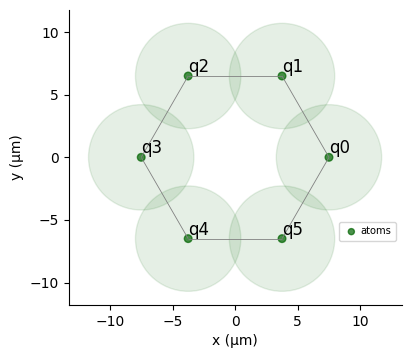

In [11]:
blockade_radius = protocol.device.rydberg_blockade_radius(2 * protocol.protocol.J)

protocol.register.draw(
    blockade_radius=blockade_radius,
    draw_half_radius=True,
    draw_graph=True,
)

In [25]:
bitstrings = protocol.run(noisy=False)

In [26]:
mbqs = MBQS(bitstrings, threshold=0.1, L=6)
mbqs.compute_metric()

(np.float64(0.10002680552812526),
 np.float64(0.09563817903329037),
 <TestSuccess.FAILED: -1>)

### Sequence of system sizes

In [23]:
def compute_bitstrings(*, L_min=3, L_max=6, shots=1000, noisy=False):
    bitstrings = {}

    for L in range(L_min, L_max + 1):
        protocol = Protocol(L=L, a=a)
        bitstrings[L] = protocol.run(shots=shots, noisy=noisy)

    return bitstrings


def display_results(score, history):

    print(f"Score = {score}")
    print()
    for L, values in history.items():
        text = f"- L = {L}, "
        text += f"metric = {values['metric']:.2f} ± {values['metric_err']:.2f} "
        text += f"({str(values['success'])})"
        print(text)

In [24]:
bitstrings = compute_bitstrings(noisy=False)

mbqs = MBQS(bitstrings, threshold=0.2)
score, history = mbqs.compute_score()

display_results(score, history)

/data/appdata/nextcloud/Documents/Projets/Recherche/Codes/Quantum computing/mbqs/.venv/lib/python3.12/site-packages/pulser/sequence/sequence.py:1323: UserWarning: A duration of 830 ns is not a multiple of the channel's clock period (4 ns). It was rounded up to 832 ns.
  self._add(
/data/appdata/nextcloud/Documents/Projets/Recherche/Codes/Quantum computing/mbqs/.venv/lib/python3.12/site-packages/pulser/sequence/sequence.py:1323: UserWarning: A duration of 1063 ns is not a multiple of the channel's clock period (4 ns). It was rounded up to 1064 ns.
  self._add(
/data/appdata/nextcloud/Documents/Projets/Recherche/Codes/Quantum computing/mbqs/.venv/lib/python3.12/site-packages/pulser/sequence/sequence.py:1323: UserWarning: A duration of 1234 ns is not a multiple of the channel's clock period (4 ns). It was rounded up to 1236 ns.
  self._add(


Score = 5

- L = 3, metric = 0.07 ± 0.12 (success)
- L = 4, metric = 0.05 ± 0.12 (success)
- L = 5, metric = 0.01 ± 0.11 (success)
- L = 6, metric = 0.12 ± 0.09 (undecided)


In [16]:
bitstrings = compute_bitstrings(noisy=True)

mbqs = MBQS(bitstrings, threshold=0.2)
score, history = mbqs.compute_score()

display_results(score, history)

/data/appdata/nextcloud/Documents/Projets/Recherche/Codes/Quantum computing/mbqs/.venv/lib/python3.12/site-packages/pulser/sequence/sequence.py:1323: UserWarning: A duration of 830 ns is not a multiple of the channel's clock period (4 ns). It was rounded up to 832 ns.
  self._add(
/data/appdata/nextcloud/Documents/Projets/Recherche/Codes/Quantum computing/mbqs/.venv/lib/python3.12/site-packages/pulser/sequence/sequence.py:1323: UserWarning: A duration of 1063 ns is not a multiple of the channel's clock period (4 ns). It was rounded up to 1064 ns.
  self._add(
/data/appdata/nextcloud/Documents/Projets/Recherche/Codes/Quantum computing/mbqs/.venv/lib/python3.12/site-packages/pulser/sequence/sequence.py:1323: UserWarning: A duration of 1234 ns is not a multiple of the channel's clock period (4 ns). It was rounded up to 1236 ns.
  self._add(


Score = 5

- L = 3, metric = 0.05 ± 0.03 (success)
- L = 4, metric = 0.05 ± 0.03 (success)
- L = 5, metric = 0.09 ± 0.02 (success)
- L = 6, metric = 0.35 ± 0.02 (failed)
